In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
filePath = 'headToHaed_data.csv'
df = pd.read_csv(filePath)
df

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,...,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts,B365>2.5_missing,B365<2.5_missing,h2h_home_wins_last5,home_league_position,away_league_position,position_diff
0,2002-08-27,0.0,1.0,A,0.0,1.0,A,A Wiley,10.0,7.0,...,0.0,2.0,2.0,1.0,1,1,0,1,1,0
1,2002-08-27,5.0,2.0,H,3.0,0.0,H,P Durkin,10.0,8.0,...,3.0,0.0,1.0,0.0,1,1,0,3,3,0
2,2002-08-28,1.0,1.0,D,0.0,0.0,D,C Foy,12.0,10.0,...,1.0,3.0,2.0,3.0,1,1,0,5,5,0
3,2002-08-28,0.0,1.0,A,0.0,0.0,D,M Halsey,20.0,9.0,...,3.0,0.0,0.0,1.0,1,1,0,7,7,0
4,2002-08-28,1.0,1.0,D,0.0,0.0,D,E Wolstenholme,11.0,5.0,...,1.0,0.0,2.0,0.0,1,1,0,9,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3169,2023-12-30,3.0,2.0,H,2.0,1.0,H,S Attwell,19.0,9.0,...,11.0,1.6,0.8,7.0,0,0,0,14,16,-2
3170,2023-12-31,2.0,1.0,H,1.0,1.0,D,J Smith,15.0,13.0,...,6.0,1.8,1.2,10.0,0,0,0,19,4,15
3171,2023-12-31,3.0,1.0,H,1.0,0.0,H,S Hooper,12.0,24.0,...,10.0,2.6,1.0,13.0,0,0,1,5,17,-12
3172,2024-01-01,4.0,2.0,H,0.0,0.0,D,A Taylor,34.0,5.0,...,11.0,1.0,1.6,6.0,0,0,2,2,8,-6


              precision    recall  f1-score   support

           0       0.53      0.49      0.51       307
           1       0.55      0.60      0.58       328

    accuracy                           0.54       635
   macro avg       0.54      0.54      0.54       635
weighted avg       0.54      0.54      0.54       635



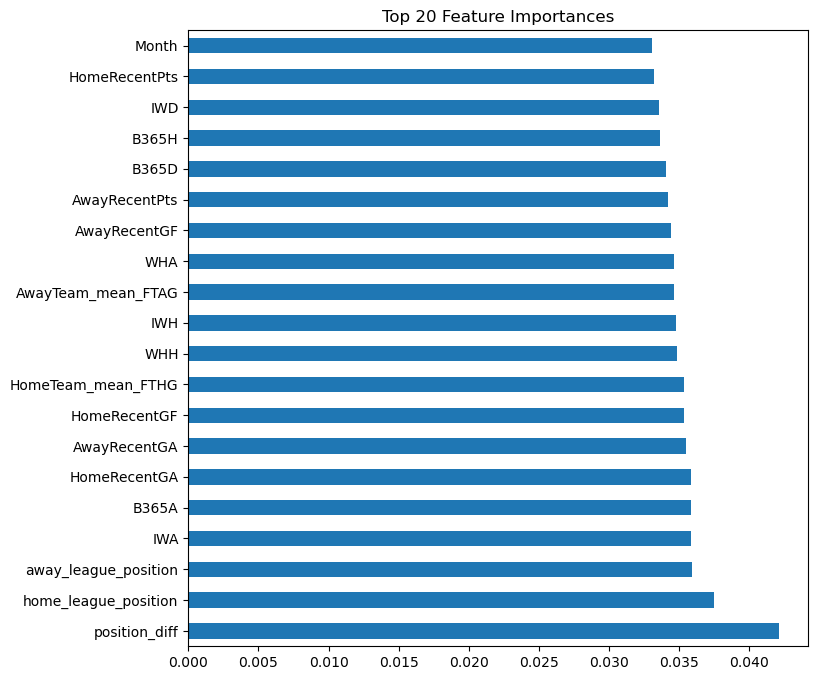

In [18]:
cols_to_drop = [
    'GoalsOver2_5', 'TotalGoals', 'FTHG', 'FTAG',
    'HTHG', 'HTAG',
    'HS', 'AS', 'HST', 'AST',  
    'HC', 'AC',               
    'HF', 'AF',               
    'HY', 'AY',               
    'HR', 'AR',               
    'FTR_H', 'FTR_A', 'FTR_D',
    'HTR_H', 'HTR_A', 'HTR_D',
   
    'FTR', 'HTR',
   
    'HomeTeam', 'AwayTeam',
   
    'Date', 'Referee'
]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['GoalsOver2_5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh', figsize=(8, 8))
plt.title('Top 20 Feature Importances')
plt.show()

In [28]:
print(feat_importances)

IWH              0.051775
IWD              0.046344
IWA              0.055277
WHH              0.055340
WHD              0.045337
                   ...   
HomeRecentGA     0.050230
HomeRecentPts    0.048478
AwayRecentGF     0.050900
AwayRecentGA     0.052525
AwayRecentPts    0.049671
Length: 107, dtype: float64


In [29]:
feat_importances.to_string('feature_importances.txt')